Load Dataset from DeepLoc


In [33]:
import pandas as pd

df = pd.read_csv("https://services.healthtech.dtu.dk/services/DeepLoc-2.0/data/Swissprot_Train_Validation_dataset.csv")

In [34]:
df.head()

,Unnamed: 0,ACC,Kingdom,Partition,Membrane,Cytoplasm,Nucleus,Extracellular,Cell membrane,Mitochondrion,Plastid,Endoplasmic reticulum,Lysosome/Vacuole,Golgi apparatus,Peroxisome,Sequence
0,0,Q28165,Metazoa,4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAAAGAAGGRGSGPGRRRHLVPGAGGEAGEGAPGGAGDY...
1,1,Q86U42,Metazoa,4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAAAGAAGGRGSGPGRRRHLVPGAGGEAGEGAPGGAGDY...
2,2,Q0GA42,Metazoa,3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAALGVRLRDCCSRGAVLLLFFSLSPRPPAAAAWLLGLR...
3,3,P82349,Metazoa,1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAATEQQGSNGPVKKSMREKAVERRNVNKEHNSNFKAGY...
4,4,Q7L5N1,Metazoa,1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAAAAAAAAATNGTGGSSGMEVDAAVVPSVMACGVTGSVSVALHPL...


Extract Cytoplasm Presence Data

In [35]:
import numpy as np

y_data = df["Cytoplasm"].to_list()
y = 5
print(f"First {y} Entries: {y_data[:y]}")

First 5 Entries: [1.0, 1.0, 0.0, 1.0, 1.0]


Extract Protein Sequences

In [36]:
x_data = df["Sequence"].to_list()
x = 4
print(f"{x}th Entries: {x_data[x]}")

4th Entries: MAAAAAAAAATNGTGGSSGMEVDAAVVPSVMACGVTGSVSVALHPLVILNISDHWIRMRSQEGRPVQVIGALIGKQEGRNIEVMNSFELLSHTVEEKIIIDKEYYYTKEEQFKQVFKELEFLGWYTTGGPPDPSDIHVHKQVCEIIESPLFLKLNPMTKHTDLPVSVFESVIDIINGEATMLFAELTYTLATEEAERIGVDHVARMTATGSGENSTVAEHLIAQHSAIKMLHSRVKLILEYVKASEAGEVPFNHEILREAYALCHCLPVLSTDKFKTDFYDQCNDVGLMAYLGTITKTCNTMNQFVNKFNVLYDRQGIGRRMRGLFF


Extract Features: Amino acid normalized frequency count and sequence length

In [37]:
amino_acids = np.array(["A", "R", "N", "D", "C", "Q", "E", "G", "H", "I","L", "K", "M", "F", "P","S", "T", "W","Y","V"])

features = []
for seq in x_data: 
    if seq == " ":
        continue
    seq_length = len(seq)
    feature_vector = [seq_length]
    for amino in amino_acids:
        feature_vector.append(seq.count(amino)/seq_length)
    features.append(feature_vector)


print(f"First Entry: {features[:2]}")

First Entry: [[306, 0.11437908496732026, 0.0915032679738562, 0.03594771241830065, 0.032679738562091505, 0.006535947712418301, 0.013071895424836602, 0.13398692810457516, 0.13071895424836602, 0.013071895424836602, 0.032679738562091505, 0.049019607843137254, 0.032679738562091505, 0.0196078431372549, 0.026143790849673203, 0.09477124183006536, 0.06862745098039216, 0.029411764705882353, 0.0032679738562091504, 0.032679738562091505, 0.0392156862745098], [306, 0.11437908496732026, 0.0915032679738562, 0.032679738562091505, 0.032679738562091505, 0.006535947712418301, 0.013071895424836602, 0.13398692810457516, 0.13071895424836602, 0.013071895424836602, 0.032679738562091505, 0.049019607843137254, 0.032679738562091505, 0.0196078431372549, 0.026143790849673203, 0.09803921568627451, 0.06862745098039216, 0.029411764705882353, 0.0032679738562091504, 0.032679738562091505, 0.0392156862745098]]


In [38]:
nsamples =  len(x_data)
indices = np.arange(nsamples)
np.random.shuffle(indices)

train_split = int(nsamples*0.7)
test_split = int(nsamples*0.2) + train_split
train_idx, test_idx, validation_idx = indices[:train_split], indices[train_split:test_split], indices[test_split:]

print(f"train, test: {train_idx}")

train, test: [ 5914  7074  2086 ... 25624  4664 21596]


Data splitting for Testing (70%), Training (20%), and Validation (10%)

In [39]:

X = np.array(features)
y = np.array(y_data)

X_train, y_train = X[train_idx], y[train_idx]

X_test, y_test = X[test_idx], y[test_idx]
    
X_valid, y_valid = X[validation_idx], y[validation_idx]


print(X.shape)
print(X_train.shape)
print(X_test.shape)
print(X_valid.shape)
print(f"Y train_shape: {y_train.shape}")

(28303, 21)
(19812, 21)
(5660, 21)
(2831, 21)
Y train_shape: (19812,)


Standardization using Z-score

In [40]:
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
std[std == 0] = 1

X_train = (X_train - mean)/std
print(X_train)
X_test = (X_test - mean)/std

X_valid = (X_valid - mean)/std


[[-0.11788227  0.09576129 -1.00378597 ...  2.12887411  0.51013982
   1.32311687]
 [-0.09913502  0.11595406 -0.58058597 ... -0.22702083 -1.2490879
  -1.3035762 ]
 [-0.24161412  0.34206301  0.7160528  ... -0.02401668  1.08061373
   1.29139519]
 ...
 [ 1.51312843 -0.16282148  0.06036289 ... -0.60988685 -0.73587128
   0.74832889]
 [-0.11413282  1.52194772 -1.37759196 ... -1.1379201  -0.51243428
   3.23616703]
 [ 0.10333527 -0.24749816  0.7982464  ... -0.42876799  1.06090232
  -0.87490339]]


In [48]:
import importlib
import protein_classifier

importlib.reload(protein_classifier)
from protein_classifier import ProteinClassifier

model = ProteinClassifier(x_train=X_train, y_train=y_train, x_test=X_test, y_test=y_test, x_valid=X_valid, y_valid=y_valid)

losses = model.train_cross_entropy()


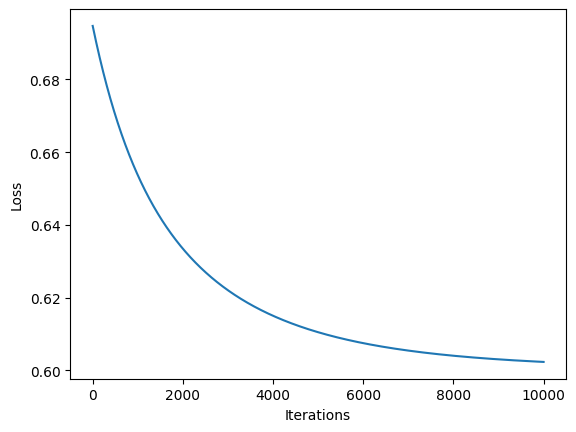

In [49]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()



In [ ]:
y_pred = model.predict(X_test)
correct = (y_pred == y_test)
accuracy = np.mean(correct)

print(f"Accuracy: {accuracy}%")